# Exploratory Data Analysis of Titanic Dataset

## Data Analyst Internship – Task 5

### Objective
To perform Exploratory Data Analysis (EDA) on the Titanic dataset and identify important patterns, trends, relationships, and anomalies using statistical analysis and data visualization.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Dataset
Titanic Dataset

In [2]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 12


In [7]:
print("Column names:")
print(df.columns.tolist())

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [11]:
# Checking missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


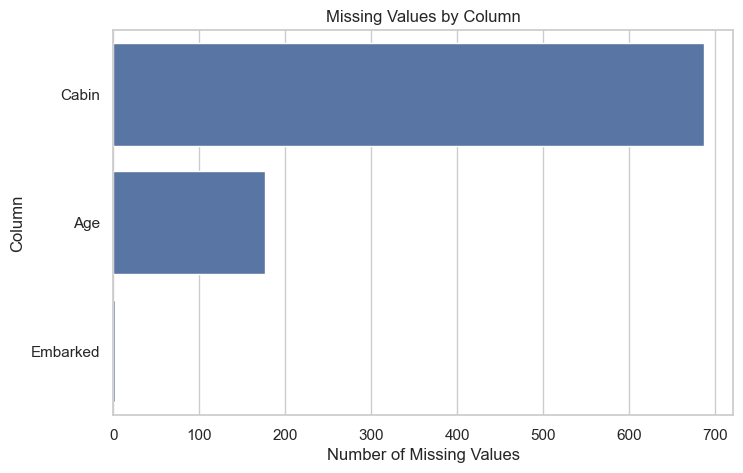

In [13]:
missing_plot = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    by="Missing Values",
    ascending=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=missing_plot["Missing Values"],
    y=missing_plot.index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")

plt.show()

### Observation

The missing-value analysis shows that missing data is not distributed equally across all columns. The Age, Cabin, and Embarked columns contain missing observations, with Cabin having a particularly large amount of missing data. These missing values should be considered before performing further analysis.

In [15]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Observation

Duplicate rows were checked to ensure that repeated records do not affect the analysis. The result indicates the number of duplicate observations present in the dataset.

In [17]:
print("Survival counts:")
print(df["Survived"].value_counts())

Survival counts:
Survived
0    549
1    342
Name: count, dtype: int64


In [18]:
print("Gender counts:")
print(df["Sex"].value_counts())

Gender counts:
Sex
male      577
female    314
Name: count, dtype: int64


In [19]:
print("Passenger class counts:")
print(df["Pclass"].value_counts().sort_index())

Passenger class counts:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [20]:
print("Embarkation counts:")
print(df["Embarked"].value_counts())

Embarkation counts:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


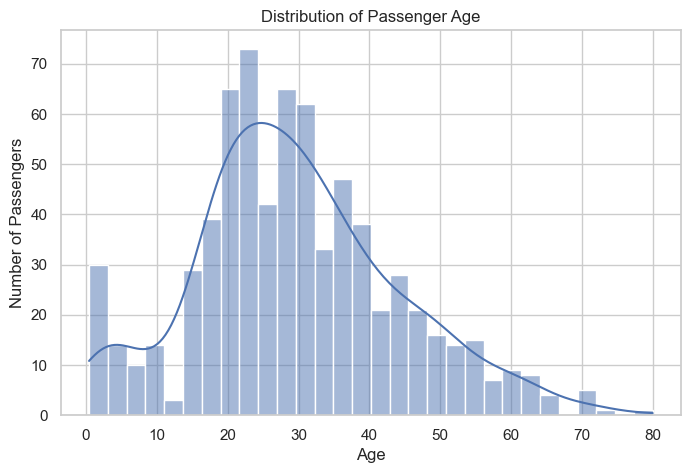

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

The histogram shows the distribution of passenger ages. Most passengers are concentrated within the younger and middle-age groups, while relatively fewer passengers are present at very high ages. The KDE curve helps visualize the overall shape of the age distribution.

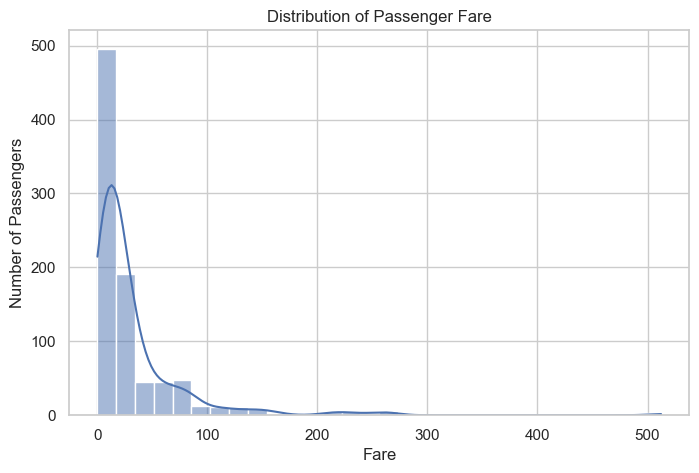

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Fare", bins=30, kde=True)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

The fare distribution is strongly concentrated toward lower fare values. A smaller number of passengers paid considerably higher fares, resulting in a long right tail in the distribution.

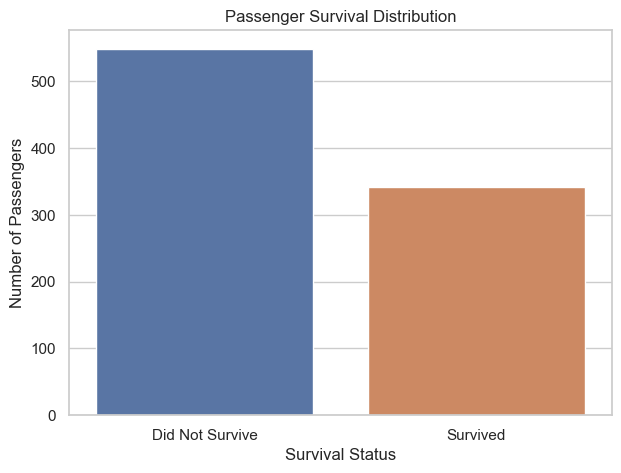

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Survived", hue="Survived", legend=False)

plt.title("Passenger Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

plt.show()

### Observation

The number of passengers who did not survive is higher than the number of passengers who survived. The dataset contains 549 passengers who did not survive and 342 passengers who survived.

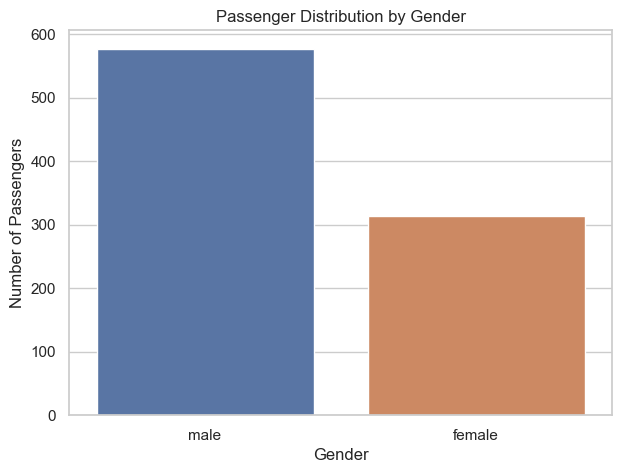

In [27]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Sex", hue="Sex", legend=False)

plt.title("Passenger Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

The dataset contains more male passengers than female passengers. There are 577 male passengers and 314 female passengers.

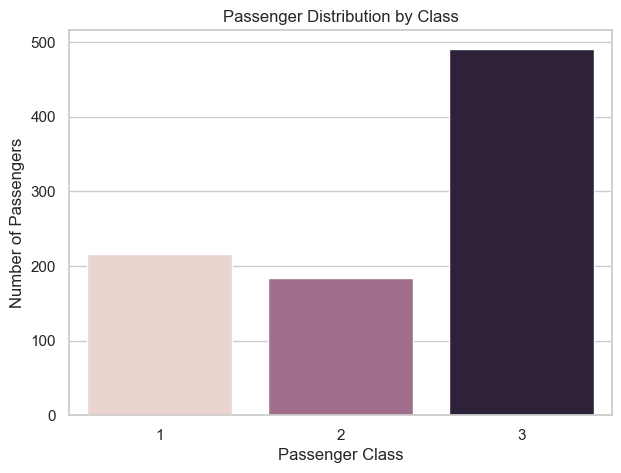

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Pclass", hue="Pclass", legend=False)

plt.title("Passenger Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

Third-class passengers form the largest passenger group, followed by first-class and second-class passengers. There are 491 passengers in third class, 216 in first class and 184 in second class.

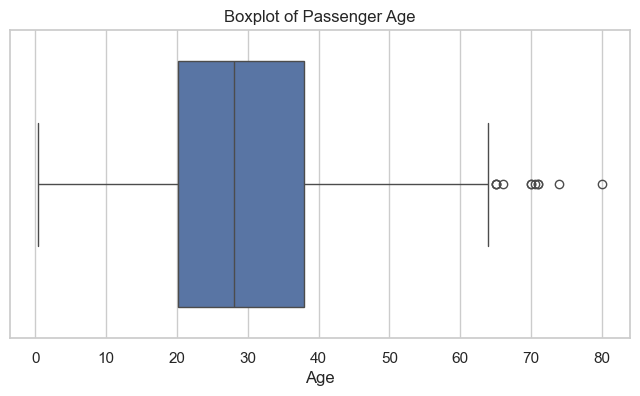

In [31]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Age"])

plt.title("Boxplot of Passenger Age")
plt.xlabel("Age")

plt.show()

### Observation

The boxplot shows the median, interquartile range and potential outliers in passenger age. It provides a compact view of the spread of ages and helps identify unusually high or low age observations.

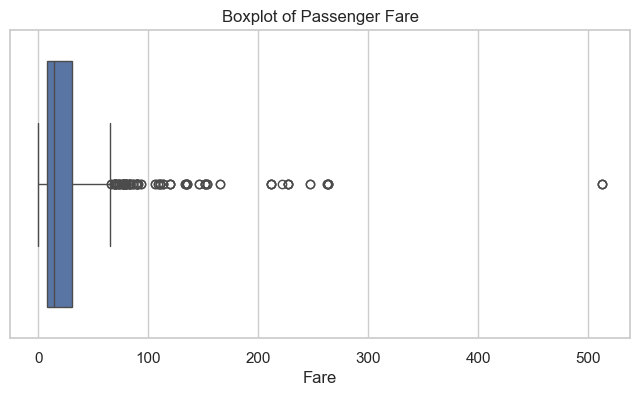

In [33]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Fare"])

plt.title("Boxplot of Passenger Fare")
plt.xlabel("Fare")

plt.show()

### Observation

The fare boxplot shows a wide spread in passenger fares and several potential high-value outliers. These observations indicate that some passengers paid substantially higher fares than most passengers.

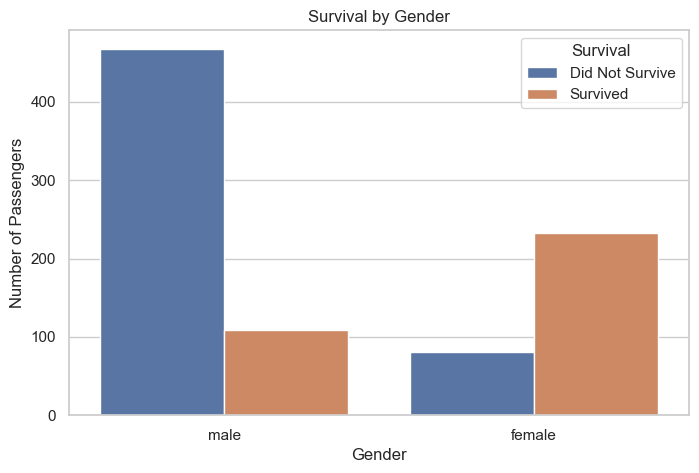

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(title="Survival", labels=["Did Not Survive", "Survived"])

plt.show()

### Observation

The plot shows a clear difference in survival outcomes between male and female passengers. Survival was more common among female passengers, while a larger number of male passengers did not survive.

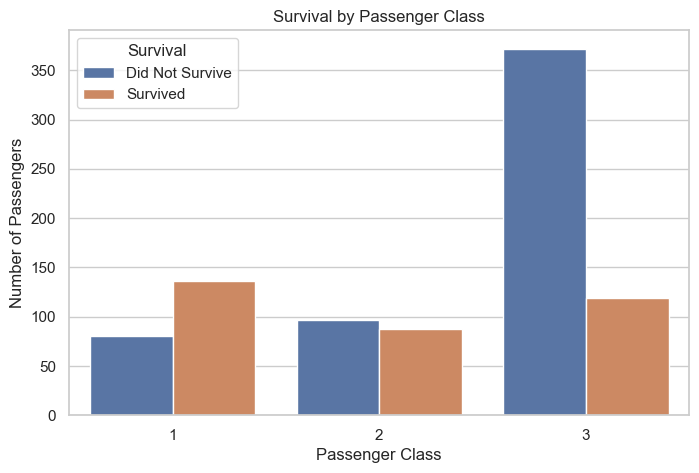

In [37]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(title="Survival", labels=["Did Not Survive", "Survived"])

plt.show()

### Observation

Survival outcomes vary across passenger classes. First-class passengers show a higher proportion of survivors, while third-class passengers have a larger number of non-survivors. This indicates an association between passenger class and survival.

In [39]:
class_survival = df.groupby("Pclass")["Survived"].mean() * 100

print("Survival rate by passenger class:")
print(class_survival)

Survival rate by passenger class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


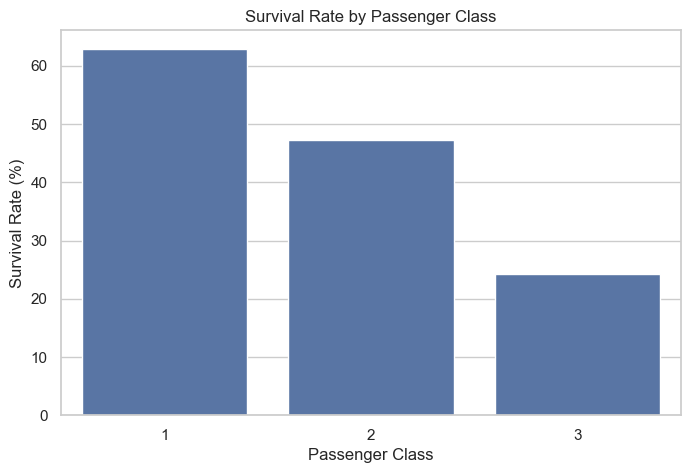

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=class_survival.index,
    y=class_survival.values
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

### Observation

The survival rate differs across passenger classes. The survival rate is higher among first-class passengers and lower among third-class passengers, indicating that passenger class is an important factor associated with survival.

In [42]:
gender_survival = df.groupby("Sex")["Survived"].mean() * 100

print("Survival rate by gender:")
print(gender_survival)

Survival rate by gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


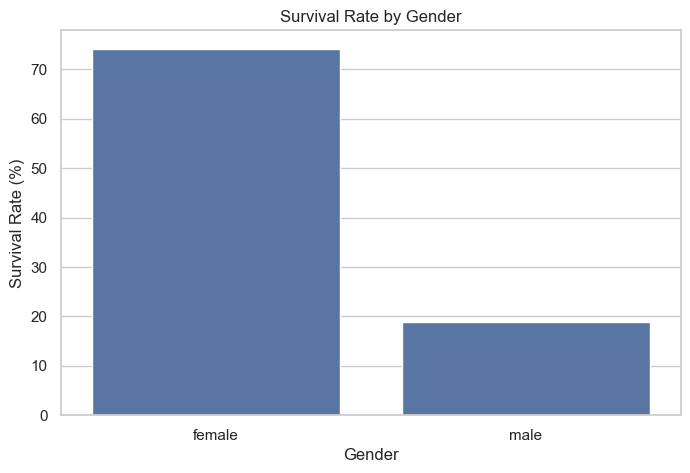

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=gender_survival.index,
    y=gender_survival.values
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

plt.show()

### Observation

The survival rate differs substantially between genders. Female passengers have a considerably higher survival rate than male passengers, showing a strong association between gender and survival.


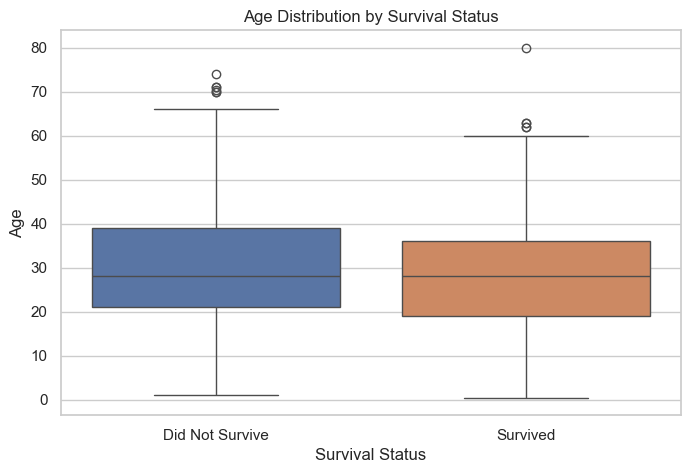

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Age",
    hue="Survived",
    legend=False
)

plt.xticks([0, 1], ["Did Not Survive", "Survived"])

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Age")

plt.show()

### Observation

The boxplot compares the age distributions of survivors and non-survivors. It helps compare the median age, spread and potential outliers between the two groups.

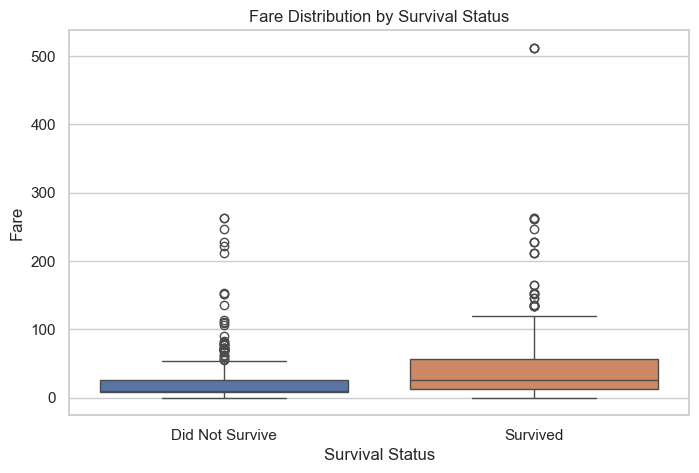

In [47]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare",
    hue="Survived",
    legend=False
)

plt.xticks([0, 1], ["Did Not Survive", "Survived"])

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Fare")

plt.show()

### Observation

The fare distributions differ between survivors and non-survivors. The plot also shows several high-fare observations, indicating that fare contains potential outliers.

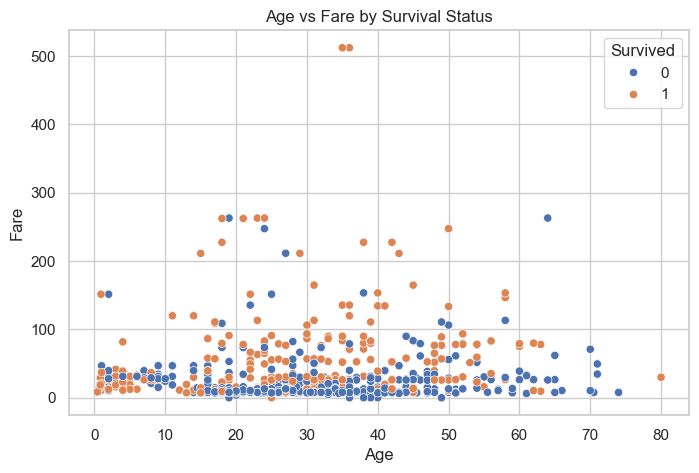

In [49]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived"
)

plt.title("Age vs Fare by Survival Status")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

### Observation

The scatterplot shows the relationship between passenger age and fare while distinguishing passengers by survival status. The observations are widely distributed, and some high-fare observations can be seen as potential outliers.

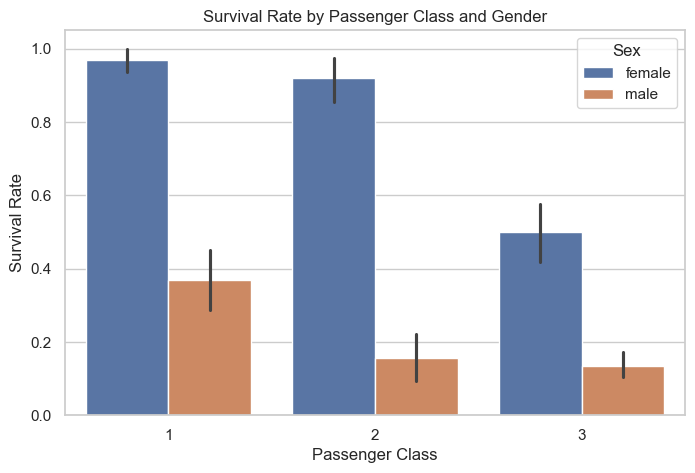

In [51]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Observation

The survival rate varies across both passenger class and gender. The visualization shows that survival outcomes are influenced by the combination of these two passenger characteristics rather than by considering either variable alone.

In [53]:
numeric_cols = df.select_dtypes(include=np.number)

correlation_matrix = numeric_cols.corr()

correlation_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


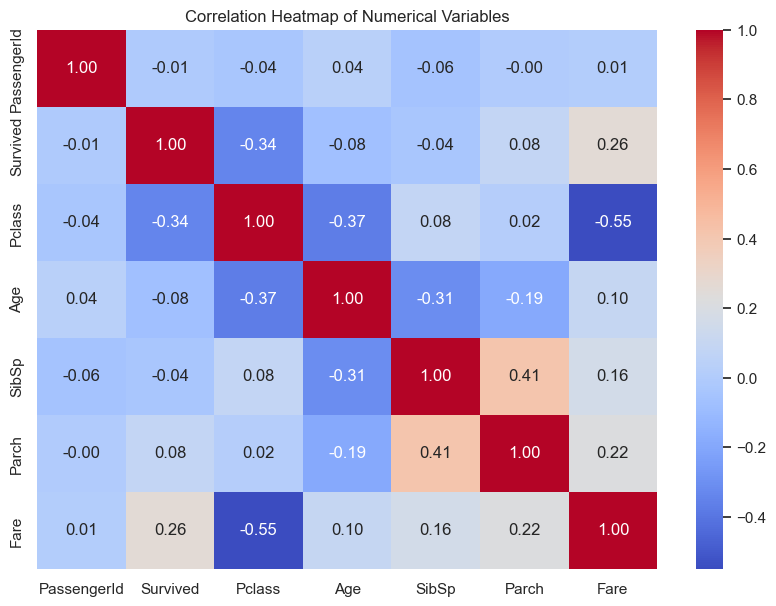

In [54]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

### Observation

The correlation heatmap shows the strength and direction of linear relationships among numerical variables. Positive values indicate positive relationships, while negative values indicate negative relationships. The heatmap makes it easier to identify variables with relatively stronger or weaker associations.

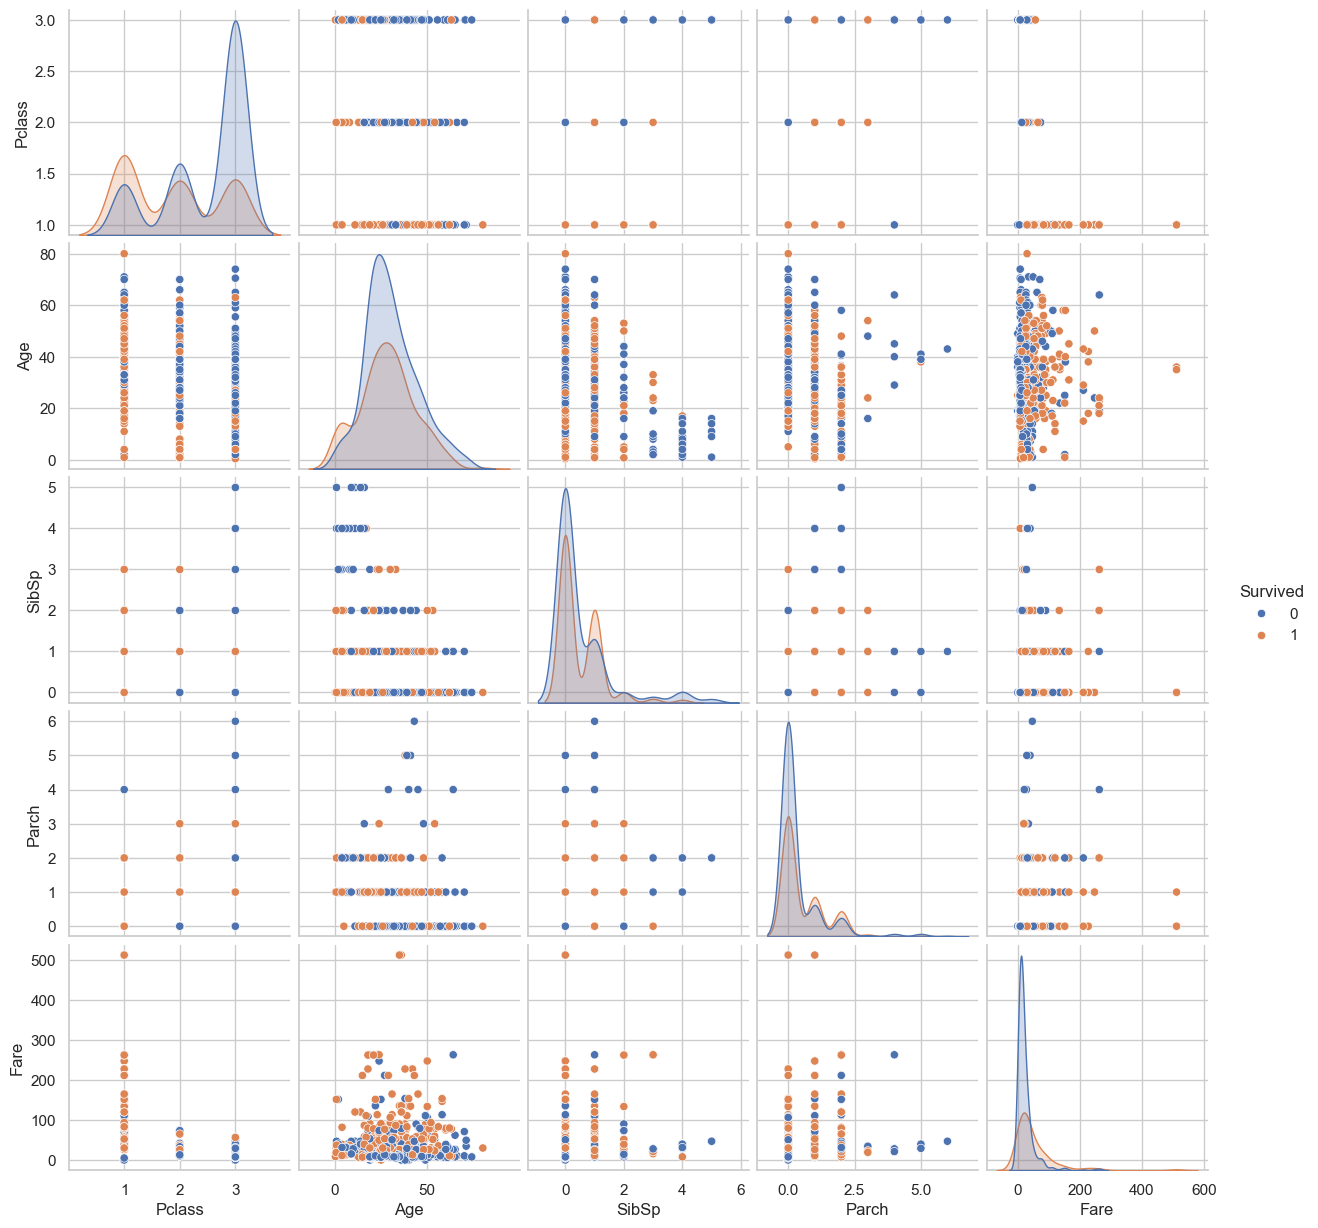

In [56]:
pairplot_data = df[
    ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
].dropna()

sns.pairplot(
    pairplot_data,
    hue="Survived"
)

plt.show()

### Observation

The pairplot provides a multivariate view of relationships among the selected numerical variables. It helps identify distributions, possible trends, clusters and outliers while also showing differences between the survival groups.

In [58]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Fare Outliers:", len(fare_outliers))

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
Number of Fare Outliers: 116


In [59]:
fare_outliers[["PassengerId", "Survived", "Pclass", "Age", "Fare"]].head(10)

,PassengerId,Survived,Pclass,Age,Fare
1,2,1,1,38.0,71.2833
27,28,0,1,19.0,263.0000
31,32,1,1,NaN,146.5208
34,35,0,1,28.0,82.1708
52,53,1,1,49.0,76.7292
61,62,1,1,38.0,80.0000
62,63,0,1,45.0,83.4750
72,73,0,2,21.0,73.5000
88,89,1,1,23.0,263.0000
102,103,0,1,21.0,77.2875


### Observation

The IQR method identifies observations whose fare values fall outside the lower and upper bounds. These observations are treated as potential outliers and should be investigated rather than automatically removed, since unusually high fares may represent genuine passengers rather than data errors.

In [61]:
print("Overall Survival Rate:")
print(df["Survived"].mean() * 100)

print("\nSurvival Rate by Gender:")
print(df.groupby("Sex")["Survived"].mean() * 100)

print("\nSurvival Rate by Passenger Class:")
print(df.groupby("Pclass")["Survived"].mean() * 100)

Overall Survival Rate:
38.38383838383838

Survival Rate by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival Rate by Passenger Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


# Key Findings

1. The dataset contains 891 passenger records and 12 variables.

2. There are 549 passengers who did not survive and 342 passengers who survived.

3. The dataset contains more male passengers (577) than female passengers (314).

4. Third-class passengers form the largest passenger group, with 491 passengers.

5. Missing values are present in variables such as Age, Cabin and Embarked, with Cabin containing a particularly large amount of missing data.

6. The fare distribution is right-skewed and contains several high-value potential outliers.

7. Survival outcomes differ considerably by gender, with female passengers showing a higher survival rate than male passengers.

8. Survival rates also differ across passenger classes, with first-class passengers showing better survival outcomes than third-class passengers.

9. The correlation heatmap helps identify relationships among numerical variables.

10. The pairplot and scatterplot provide additional views of relationships, distributions and potential outliers.

11. Overall, gender, passenger class and fare show important associations with survival in the Titanic dataset.

# Conclusion

Exploratory Data Analysis was successfully performed on the Titanic dataset using Python, Pandas, NumPy, Matplotlib and Seaborn.

The analysis covered dataset structure, descriptive statistics, missing-value analysis, categorical analysis, univariate analysis, bivariate analysis, multivariate analysis, histograms, boxplots, scatterplots, a correlation heatmap, pairplot and outlier analysis.

The analysis shows that passenger survival was strongly associated with gender and passenger class. Female passengers had a higher survival rate than male passengers, while first-class passengers had better survival outcomes than third-class passengers. The fare variable also showed a right-skewed distribution with several high-value potential outliers.

Overall, the EDA provides useful insights into the factors associated with passenger survival and demonstrates how statistical analysis and data visualization can be used to understand a real-world dataset.

# Project Summary

### Dataset
Titanic Dataset

### Records
891 passengers

### Variables
12 columns

### Main Analysis Performed
- Dataset overview and descriptive statistics
- Missing-value analysis
- Duplicate-value check
- Categorical variable analysis
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Correlation analysis
- Outlier analysis

### Visualizations
- Histograms
- Countplots
- Boxplots
- Scatterplot
- Barplots
- Correlation heatmap
- Pairplot

### Main Insights
Gender and passenger class show strong differences in survival outcomes. Fare has a highly right-skewed distribution with several potential outliers. The analysis demonstrates important patterns and relationships within the Titanic dataset.